In [1]:
import sys
from pathlib import Path

# Quick-fix: add <repo-root>/src to the import path so `import risk...` works
PROJECT_ROOT = Path.cwd().parents[2]
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("Added to sys.path:", SRC_PATH)

Added to sys.path: /Users/susmitasingh/Documents/GitHub/Portfolio_Risk_Monitor/src


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from risk.returns import compute_log_returns
from risk.var_historical import historical_var


In [10]:
df = pd.read_csv("../../../data/raw/SPY.US.csv", parse_dates=["Date"], index_col="Date")

# Compute log returns
log_returns = compute_log_returns(df)

print(log_returns.head())

Date
2005-02-28   -0.006858
2005-03-01    0.005190
2005-03-02   -0.000491
2005-03-03    0.000400
2005-03-04    0.012508
Name: Close, dtype: float64


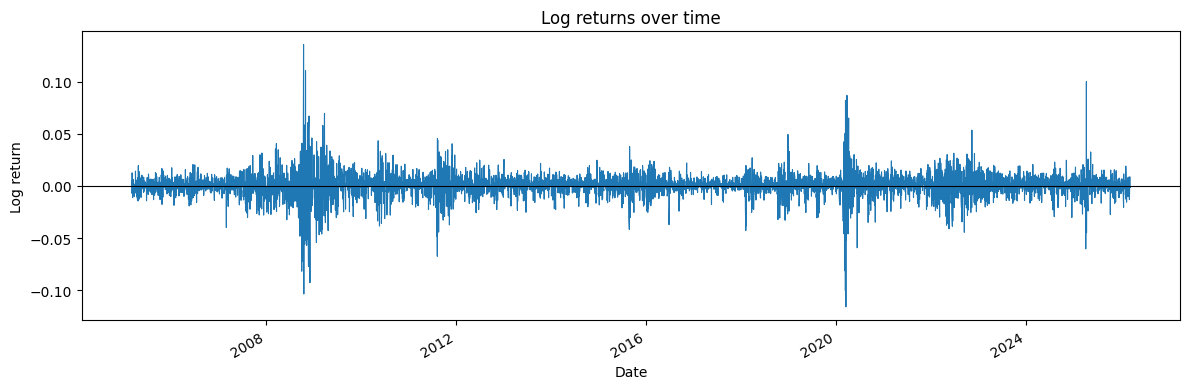

In [11]:
# Time series plot of log returns
ax = log_returns.plot(figsize=(12, 4), linewidth=0.8)
ax.set_title("Log returns over time")
ax.set_xlabel("Date")
ax.set_ylabel("Log return")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


In [13]:
var_95 = historical_var(log_returns, alpha=0.05)


In [14]:
var_95

np.float64(-0.017817414381536875)